## MRI Data Exploration - EDA

Dataset: Brain Tumor MRI Dataset

Goal: This notebook explores the Brain Tumor MRI Dataset used for the image classification project.

___

 ### Setup Project Root
 
 This helps configure the Jupyter notebook to the desired working directory

In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Current Directory:", os.getcwd())

Current Directory: c:\Users\Steph\OneDrive\Desktop\All Other Code\mri-brain-scan\MRI-Brain-Scan-Project


### 1. Import Libraries

The following libraries are used for data analysis and visualization.

*Note: The custom modules in the src directory provide reusable functions for preprocessing data and generating graphs.*

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from src.database import connect_db, create_tables, populate_database

### 2. Connect to SQLite

In order to get started we must first connect to the database.

*Note: If the database doesn't exist, running the command will create one.*

In [3]:
connection = connect_db()

### 3. Create a table

Now that we've connected to the database we can start to create a table where we can store and label data.

In [4]:
create_tables(connection)

### 4. Populate the database.

Now we add the data from the dataset into the database.

*Note: The database has already been populated so it will return a message stating its populated.*

In [5]:
populate_database(connection)

Database already populated.


### 5. Verify the number of records

To make sure the data got inserted into the database, we can check if they got inserted.

In [6]:
cursor = connection.cursor()
cursor.execute("SELECT COUNT(*) FROM mri_images")
total_records = cursor.fetchone()[0]
print(f"Total records: {total_records}")

diagnosis_split_query = "SELECT split, diagnosis, COUNT(*) AS total_images FROM mri_images GROUP BY split, diagnosis ORDER BY split, diagnosis;"
diagnosis_split_df = pd.read_sql(diagnosis_split_query, connection)

print(f"Diagnosis records:\n{diagnosis_split_df}")

Total records: 7200
Diagnosis records:
      split   diagnosis  total_images
0   Testing      glioma           400
1   Testing  meningioma           400
2   Testing     notumor           400
3   Testing   pituitary           400
4  Training      glioma          1400
5  Training  meningioma          1400
6  Training     notumor          1400
7  Training   pituitary          1400


### 6. Dataset Overview

Before diving into the data, it's important to understand the size and structure of the dataset, the data types, and the statistics of said data.

In [7]:
data = "SELECT * FROM mri_images"
df = pd.read_sql(data, connection)

print('Dataset shape:', df.shape)
print('\n' + '-' * 50)

df.info()
print('\n' + '-' * 50)

print('\nDescriptive Statistics')
print(df.describe())

Dataset shape: (7200, 8)

--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         7200 non-null   int64 
 1   filename   7200 non-null   object
 2   filepath   7200 non-null   object
 3   diagnosis  7200 non-null   object
 4   split      7200 non-null   object
 5   width      7200 non-null   int64 
 6   height     7200 non-null   int64 
 7   filesize   7200 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 450.1+ KB

--------------------------------------------------

Descriptive Statistics
                id        width       height       filesize
count  7200.000000  7200.000000  7200.000000    7200.000000
mean   3600.500000   453.302917   456.899167   23312.355139
std    2078.605302   130.048964   124.402496   16300.958173
min       1.000000   150.000000   167.000000    3681.000000

### 7. Class Distribution

Now we observe what kind of Brain Tumors we are dealing with.

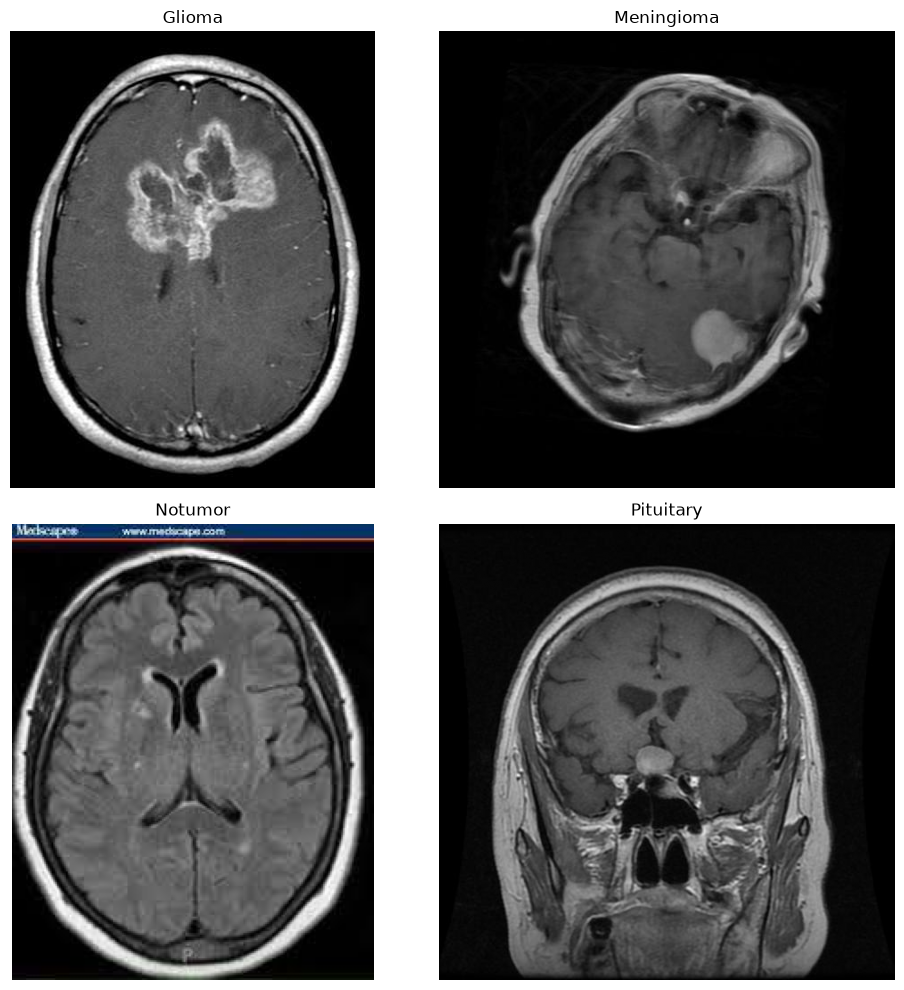

In [10]:
data = "SELECT diagnosis, filepath FROM mri_images"

df = pd.read_sql(data, connection)

sample_images = (
    df.groupby("diagnosis")
      .first()
      .reset_index()
)

fig, axes = plt.subplots(
    2, 
    2, 
    figsize=(10, 10)
)

axes = axes.flatten()

for i, row in sample_images.iterrows():

    image = Image.open(row["filepath"])

    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(row["diagnosis"].title())
    axes[i].axis("off")


plt.tight_layout()
plt.show()

### 8. Training and Testing Split

The data is split into training and testing data.

In [38]:
data = "SELECT split FROM mri_images"

df = pd.read_sql(data, connection)

display(df.head())
print('\n' + '-' * 50)
display(df.tail())

,split
0,Testing
1,Testing
2,Testing
3,Testing
4,Testing



--------------------------------------------------


,split
7195,Training
7196,Training
7197,Training
7198,Training
7199,Training


### Conclusion

This exploratory data analysis provided an overview of the Brain Tumor MRI Dataset before training the classification model.

The dataset contains 7,200 MRI images across four diagnostic categories:
- Glioma
- Meningioma
- No Tumor
- Pituitary

The analysis examined the dataset structure, class distribution, training/testing split, image dimensions, and sample MRI scans.

Overall, the images varied in resolutions, which required resizing and preprocessing before being used with the ResNet-18 deep learning model.